# Batch3_analysis.ipynb Battery Analysis

목표:
- 초기 100 cycle 기반 feature 생성
- 이상값 제거
- correlation 분석
- regression 준비


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import scipy.io as sio
import mat73


## 데이터 로딩

In [2]:
def load_mat(path):
    try:
        data = mat73.loadmat(path)
    except:
        data = sio.loadmat(path, simplify_cells=True)
    return data

DATA_DIR=Path('../data/data-30')

In [3]:
def extract_cells(batch):

    cells=[]

    n=len(batch['cycle_life'])

    for i in range(n):

        cell={}

        for key in batch.keys():

            value=batch[key]

            if isinstance(value,list):

                cell[key]=value[i]

            else:

                cell[key]=value

        cells.append(cell)

    return cells

In [4]:
DATA_DIR=Path("../data/data-30")

b3=load_mat(DATA_DIR/"2018-04-12_batchdata_updated_struct_errorcorrect.mat")

ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

## Feature Engineering (100 cycle 기준)

In [5]:
def early_mean(arr,n=100):
    arr=np.array(arr).reshape(-1)
    if len(arr)<n:
        return np.nan
    return np.mean(arr[:n])

def delta_100(arr):
    arr=np.array(arr).reshape(-1)
    if len(arr)<100:
        return np.nan
    return arr[99]-arr[0]

def delta_100_10(arr):
    arr=np.array(arr).reshape(-1)
    if len(arr)<100:
        return np.nan
    return arr[99]-arr[9]

def early_var(arr,n=100):
    arr=np.array(arr).reshape(-1)
    if len(arr)<n:
        return np.nan
    return np.var(arr[:n])

## Feature DataFrame 생성

In [6]:
def build_feature_df(cells):
    rows=[]
    for cell in cells:
        summary=cell['summary']
        row={
        'cycle_life':cell['cycle_life'],
        'IR_mean':early_mean(summary['IR']),
        'QDischarge_mean':early_mean(summary['QDischarge']),
        'Tmax_mean':early_mean(summary['Tmax']),
        'Tavg_mean':early_mean(summary['Tavg']),
        'charge_time_mean':early_mean(summary['chargetime']),
        'IR_delta':delta_100(summary['IR']),
        'QDischarge_delta':delta_100(summary['QDischarge']),
        'IR_delta_100_10':delta_100_10(summary['IR']),
        'QDischarge_delta_100_10':delta_100_10(summary['QDischarge']),
        'IR_var':early_var(summary['IR']),
        'QDischarge_var':early_var(summary['QDischarge'])
        }
        rows.append(row)
    return pd.DataFrame(rows)

## NaN 제거

In [8]:
cells = extract_cells(b3['batch'])
df = build_feature_df(cells)
df=df.dropna()
df.head()

,cycle_life,IR_mean,QDischarge_mean,Tmax_mean,Tavg_mean,charge_time_mean,IR_delta,QDischarge_delta,IR_delta_100_10,QDischarge_delta_100_10,IR_var,QDischarge_var
0,1009.0,0.015238,1.070348,33.558890,32.194400,10.042618,-0.000164,0.002882,0.000021,-0.000965,1.622416e-09,5.611718e-07
1,1063.0,0.014986,1.067687,37.985972,34.830650,10.041390,-0.000109,0.002254,0.000099,-0.001784,1.984130e-09,6.093568e-07
2,1267.0,0.014622,1.062053,40.516154,36.783146,10.043666,-0.000437,0.000613,-0.000112,-0.002174,7.514428e-09,5.839070e-07
3,1115.0,0.014999,1.064629,39.445934,36.086275,10.041507,0.000114,0.001321,0.000111,-0.001511,9.222054e-10,4.207613e-07
4,1048.0,0.015131,1.074510,32.981793,32.116222,10.045582,-0.000118,0.002118,0.000030,-0.000680,1.236579e-09,3.111678e-07


## 그래프 1 : cycle life 분포

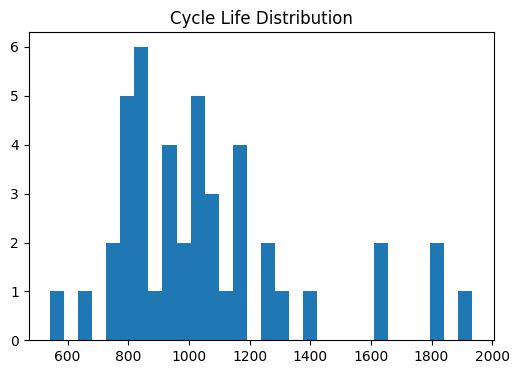

In [9]:
plt.figure(figsize=(6,4))
plt.hist(df['cycle_life'],bins=30)
plt.title('Cycle Life Distribution')
plt.show()

## 그래프 2 : feature histogram

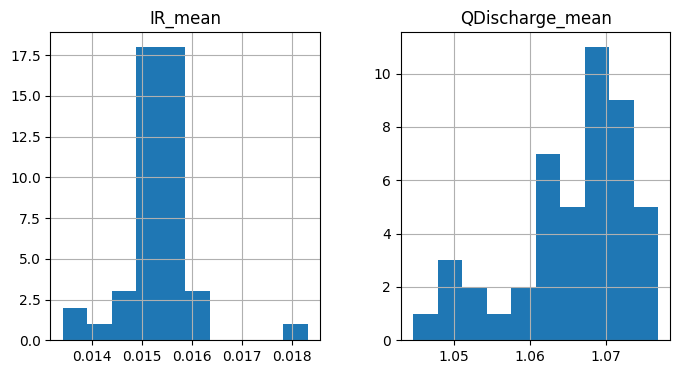

In [10]:
df[['IR_mean','QDischarge_mean']].hist(figsize=(8,4))
plt.show()

## 그래프 3 : Correlation heatmap

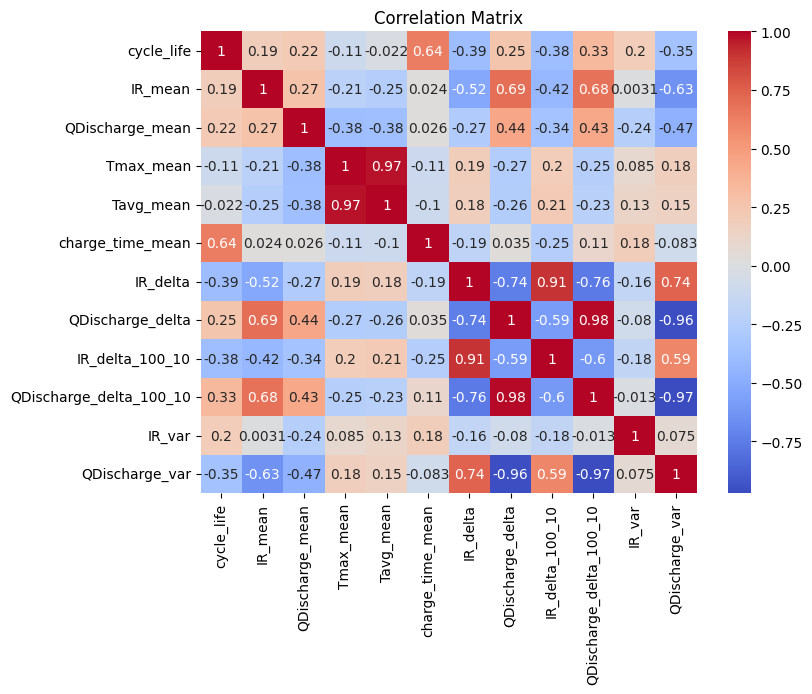

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## 그래프 4 : Scatter

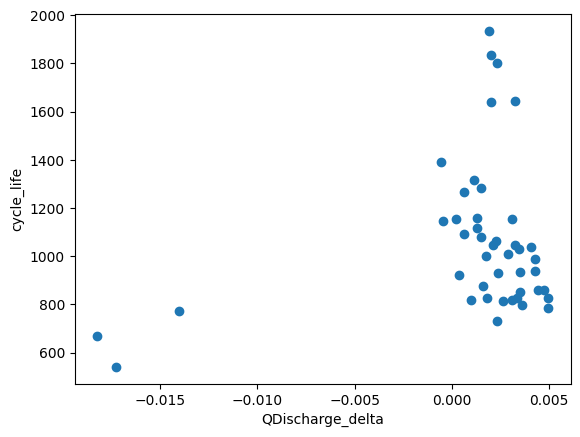

In [12]:
plt.scatter(df['QDischarge_delta'],df['cycle_life'])
plt.xlabel('QDischarge_delta')
plt.ylabel('cycle_life')
plt.show()

In [13]:
df.to_csv("../results/batch3_features.csv",index=False)